<a href="https://colab.research.google.com/github/priyanka-pandya/ML-Practicals/blob/main/combine_all_linkages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Single Linkage Silhouette Score: 0.6606668813897673
Complete Linkage Silhouette Score: 0.6606668813897673
Average Linkage Silhouette Score: 0.6339782218419878


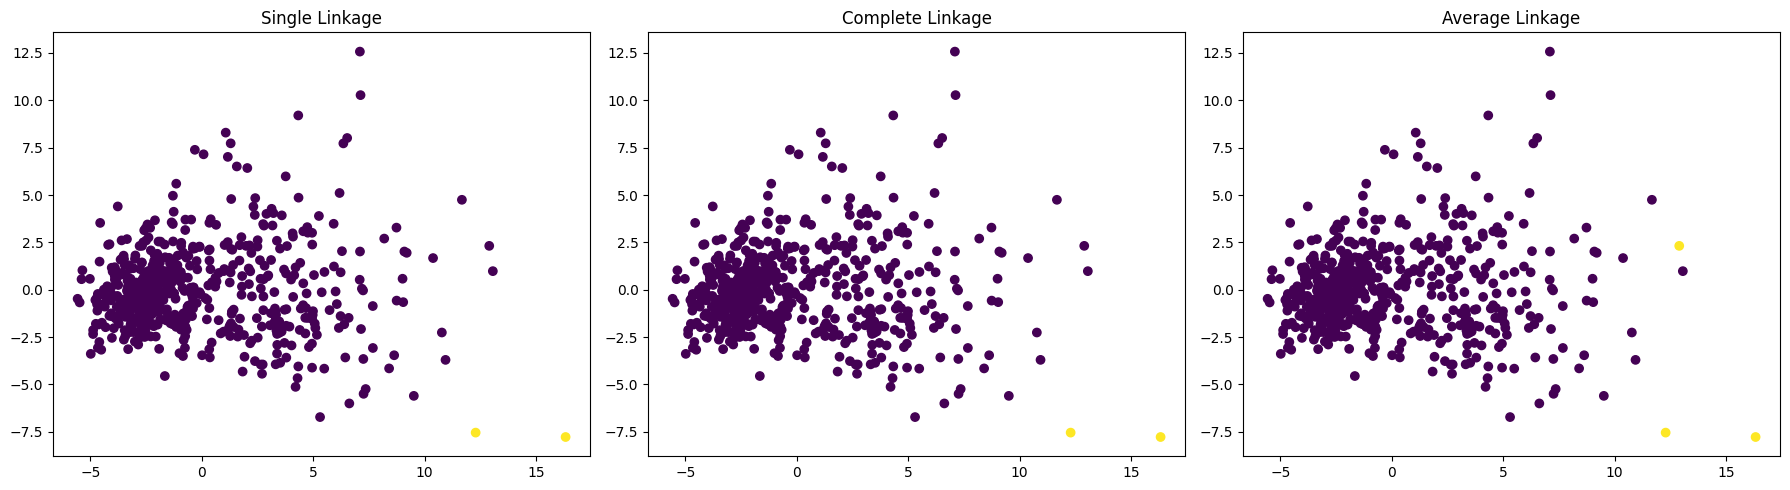

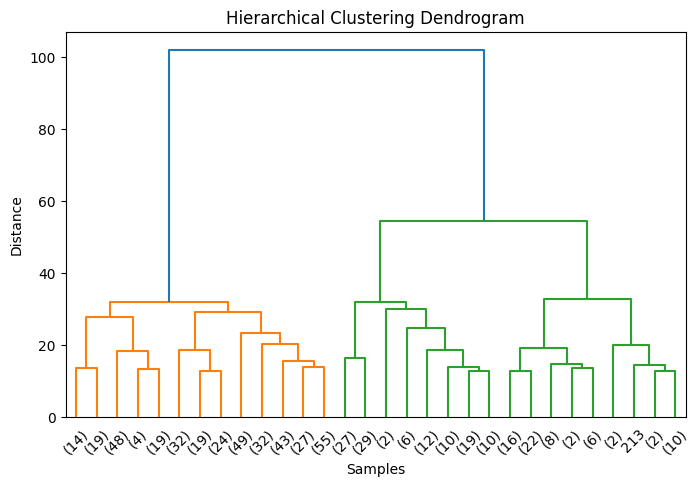

In [2]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Load dataset
cancer = load_breast_cancer()
X = cancer.data

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Linkage methods
linkages = ['single', 'complete', 'average']

plt.figure(figsize=(18, 5))

for i, method in enumerate(linkages):

    # Apply clustering
    model = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = model.fit_predict(X_scaled)

    # Silhouette score
    score = silhouette_score(X_scaled, labels)

    print(f"{method.capitalize()} Linkage Silhouette Score:", score)

    # Plot clusters
    plt.subplot(1, 3, i+1)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
    plt.title(f"{method.capitalize()} Linkage")

plt.tight_layout()
plt.show()

# -------- DENDROGRAM --------
plt.figure(figsize=(8,5))
Z = linkage(X_scaled, method='ward')  # dendrogram usually shown with ward
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()